# ColBERTv2 vs Bi-Encoder Retrieval Benchmark

End-to-end pipeline: data loading → chunking → NER classification → bi-encoder retrieval → ColBERTv2 retrieval → evaluation → visualization.

All results are written to a single JSON log file. Evaluation and visualization read exclusively from that log.

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import json
import yaml
import pandas as pd
from IPython.display import Image, display

from src.profiler import Profiler
from src.benchmark_runner import load_config, build_variant_config, run_full_benchmark

config = load_config("configs/quick_ablation.yaml")

print("Config loaded.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Default chunking strategy: {config['chunking']['strategy']}")


/1508-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/1508-project/src/colbert_retrieval.py:71: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


Config loaded.
Project root: /1508-project
Default chunking strategy: paragraph


## 1. Data Pipeline

Load KILT NQ, build reduced corpus, chunk, classify queries by NER, sample balanced groups, extract ground-truth.

In [2]:
from src.data_pipeline import run_data_pipeline
import gc

profiler = Profiler(config=config)
pipeline_out = run_data_pipeline(config, profiler)

chunks = pipeline_out["chunks"]
sampled_queries = pipeline_out["sampled_queries"]
del pipeline_out
gc.collect()

print(f"Total chunks: {len(chunks)}")
print(f"Sampled queries: {len(sampled_queries)}")
print(f"  single-entity: {sum(1 for q in sampled_queries if q['entity_group'] == 'single-entity')}")
print(f"  multi-entity:  {sum(1 for q in sampled_queries if q['entity_group'] == 'multi-entity')}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/kilt_tasks' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Total chunks: 3415
Sampled queries: 51
  single-entity: 30
  multi-entity:  21


## 2. Bi-Encoder Retrieval

Encode chunks with MiniLM, build FAISS index, retrieve top-k for each query.

In [3]:
from src.biencoder_retrieval import run_biencoder_retrieval

run_biencoder_retrieval(chunks, sampled_queries, config, profiler)
print("Bi-encoder retrieval complete.")
print(f"  Sample query recall@10: {sampled_queries[0].get('biencoder_recall_at_k', {}).get('10', 'N/A')}")

Batches: 100%|██████████| 14/14 [00:01<00:00, 12.29it/s]


Bi-encoder retrieval complete.
  Sample query recall@10: 1.0


## 3. ColBERTv2 Retrieval

Index chunks with RAGatouille ColBERTv2, retrieve top-k with late interaction scoring.

In [4]:
from src.colbert_retrieval import run_colbert_retrieval

run_colbert_retrieval(chunks, sampled_queries, config, profiler)
print("ColBERTv2 retrieval complete.")
print(f"  Sample query recall@10: {sampled_queries[0].get('colbert_recall_at_k', {}).get('10', 'N/A')}")

---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 09, 19:29:09] #> Note: Output directory results/colbert_index/colbert/indexes/colbert_benchmark already exists


[Apr 09, 19:29:09] #> Will delete 10 files already at results/colbert_index/colbert/indexes/colbert_benchmark in 20 seconds...


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


[Apr 09, 19:29:32] [0] 		 #> Encoding 3415 passages..


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


[Apr 09, 19:29:37] [0] 		 avg_doclen_est = 43.07057189941406 	 len(local_sample) = 3,415
[Apr 09, 19:29:37] [0] 		 Creating 4,096 partitions.
[Apr 09, 19:29:37] [0] 		 *Estimated* 147,086 embeddings.
[Apr 09, 19:29:37] [0] 		 #> Saving the indexing plan to results/colbert_index/colbert/indexes/colbert_benchmark/plan.json ..
used 20 iterations (1.1537s) to cluster 139732 items into 4096 clusters
[0.044, 0.044, 0.047, 0.043, 0.043, 0.044, 0.042, 0.041, 0.04, 0.043, 0.041, 0.042, 0.041, 0.043, 0.043, 0.043, 0.038, 0.041, 0.041, 0.042, 0.044, 0.044, 0.043, 0.044, 0.043, 0.044, 0.044, 0.044, 0.041, 0.044, 0.044, 0.045, 0.047, 0.041, 0.043, 0.038, 0.045, 0.043, 0.043, 0.049, 0.044, 0.043, 0.042, 0.042, 0.041, 0.041, 0.041, 0.046, 0.045, 0.04, 0.041, 0.042, 0.044, 0.044, 0.044, 0.044, 0.048, 0.043, 0.049, 0.041, 0.041, 0.044, 0.043, 0.045, 0.045, 0.044, 0.046, 0.044, 0.039, 0.041, 0.047, 0.042, 0.041, 0.044, 0.042, 0.044, 0.043, 0.048, 0.042, 0.044, 0.044, 0.043, 0.044, 0.044, 0.041, 0.043, 0

...

100%|██████████| 1/1 [00:00<00:00, 702.92it/s]

[Apr 09, 19:29:45] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 59.80it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: who donates a christmas tree to trafalgar square, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2040, 21357,  2015,  1037,  4234,  3392,  2000, 19817,
        10354,  2389,  6843,  2675,   102,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



ColBERTv2 retrieval complete.
  Sample query recall@10: 1.0


## 4. Save JSON Log & Log Per-Query Results

Write per-query results to the profiler and save the complete JSON log.

In [5]:
# Log per-query results into the profiler
for q in sampled_queries:
    record = {
        "query": q["query"],
        "entity_count": q["entity_count"],
        "entity_list": q["entity_list"],
        "entity_group": q["entity_group"],
        "ground_truth_chunk_ids": q["ground_truth_chunk_ids"],
    }
    # Bi-encoder results
    for key in ("biencoder_retrieved_ids", "biencoder_recall_at_k", "biencoder_latency_ms"):
        if key in q:
            record[key] = q[key]
    # ColBERT results
    for key in ("colbert_retrieved_ids", "colbert_recall_at_k", "colbert_latency_ms"):
        if key in q:
            record[key] = q[key]
    profiler.log_query(record)

# Store model names in metadata
profiler.data["metadata"]["models"] = config["models"]
profiler.data["metadata"]["k_values"] = config["retrieval"]["k_values"]

# Save JSON log
log_path = config["paths"]["json_log"]
profiler.save(log_path)
print(f"JSON log saved to: {log_path}")

# Verify key fields
import json
with open(log_path, "r", encoding="utf-8") as f:
    log = json.load(f)
print(f"  Stages recorded: {list(log['stages'].keys())}")
print(f"  Queries logged: {len(log['queries'])}")
print(f"  Disk sizes: {log['disk_sizes']}")
print(f"  Metadata keys: {list(log['metadata'].keys())}")

JSON log saved to: results/benchmark_log.json
  Stages recorded: ['data_loading', 'ner_classification', 'query_sampling', 'corpus_construction', 'chunking', 'biencoder_encoding', 'faiss_indexing', 'biencoder_retrieval', 'colbert_indexing', 'colbert_retrieval']
  Queries logged: 51
  Disk sizes: {'faiss_index': 5245485, 'colbert_index': 12307760}
  Metadata keys: ['timestamp', 'config', 'gpu_device', 'gpu_total_vram_bytes', 'corpus_size', 'total_chunks', 'total_queries', 'chunking', 'queries_per_group', 'colbert_index_path', 'models', 'k_values']


## 5. Evaluation

Compute Recall@k from the JSON log (reads exclusively from JSON, no recomputation).

In [6]:
from src.evaluation import run_evaluation

summary = run_evaluation(config["paths"]["json_log"])
print("Summary Statistics:")
print(summary.to_string(index=False))

Summary Statistics:
 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.061429        0.092778  0.031349
single-entity  5          0.212540        0.218889  0.006349
single-entity 10          0.260952        0.252857 -0.008095
single-entity 20          0.280714        0.277063 -0.003651
 multi-entity  1          0.111111        0.142857  0.031746
 multi-entity  5          0.244898        0.291383  0.046485
 multi-entity 10          0.307256        0.354875  0.047619
 multi-entity 20          0.368481        0.361678 -0.006803
      overall  1          0.081886        0.113399  0.031513
      overall  5          0.225864        0.248739  0.022876
      overall 10          0.280019        0.294865  0.014846
      overall 20          0.316853        0.311905 -0.004949


## 6. Visualization

Generate all charts and CSV export (reads exclusively from JSON log).

In [7]:
from src.visualize import run_visualization

output_paths = run_visualization(
    log_path=config["paths"]["json_log"],
    charts_dir=config["paths"]["charts_dir"],
    csv_path=config["paths"]["csv_output"],
)

print("Generated outputs:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")

Generated outputs:
  recall_bar_chart: results/charts/recall_bar_chart.png
  recall_histograms: ['results/charts/recall_histogram_k1.png', 'results/charts/recall_histogram_k5.png', 'results/charts/recall_histogram_k10.png', 'results/charts/recall_histogram_k20.png']
  latency_comparison: results/charts/latency_comparison.png
  index_size_comparison: results/charts/index_size_comparison.png
  summary_csv: results/summary_statistics.csv


## 7. Display Charts

In [ ]:
from IPython.display import Image, display

for name, path in output_paths.items():
    if isinstance(path, str) and path.endswith(".png"):
        print(f"\n--- {name} ---")
        display(Image(filename=path))
    elif isinstance(path, list):
        for p in path:
            print(f"\n--- {p} ---")
            display(Image(filename=p))

## 8. Profiling Summary

In [8]:
import json

with open(config["paths"]["json_log"], encoding="utf-8") as f:
    log = json.load(f)

print("=== Stage Timings ===")
for stage, info in log["stages"].items():
    vram = f", VRAM peak: {info['peak_vram_bytes']/1e9:.2f} GB" if info.get("peak_vram_bytes") else ""
    print(f"  {stage}: {info['duration_seconds']:.2f}s, RSS: {info['rss_bytes']/1e9:.2f} GB{vram}")

print(f"\n=== Disk Sizes ===")
for label, size in log["disk_sizes"].items():
    print(f"  {label}: {size/1e6:.1f} MB")

print(f"\n=== Run Metadata ===")
meta = log["metadata"]
print(f"  Timestamp: {meta['timestamp']}")
print(f"  GPU: {meta.get('gpu_device', 'None')}")
print(f"  Corpus size: {meta.get('corpus_size', 'N/A')} pages")
print(f"  Total chunks: {meta.get('total_chunks', 'N/A')}")
print(f"  Queries: {meta.get('total_queries', 'N/A')}")
print(f"  Queries per group: {meta.get('queries_per_group', 'N/A')}")

=== Stage Timings ===
  data_loading: 2.71s, RSS: 1.01 GB
  ner_classification: 1.60s, RSS: 1.03 GB
  query_sampling: 0.00s, RSS: 1.03 GB
  corpus_construction: 0.01s, RSS: 1.04 GB
  chunking: 0.23s, RSS: 1.04 GB
  biencoder_encoding: 3.44s, RSS: 1.52 GB, VRAM peak: 1.28 GB
  faiss_indexing: 0.28s, RSS: 1.52 GB, VRAM peak: 0.10 GB
  biencoder_retrieval: 0.27s, RSS: 1.53 GB, VRAM peak: 0.10 GB
  colbert_indexing: 35.12s, RSS: 2.11 GB, VRAM peak: 37.60 GB
  colbert_retrieval: 7.59s, RSS: 2.21 GB, VRAM peak: 1.10 GB

=== Disk Sizes ===
  faiss_index: 5.2 MB
  colbert_index: 12.3 MB

=== Run Metadata ===
  Timestamp: 2026-04-09T19:28:58.783734+00:00
  GPU: NVIDIA A40
  Corpus size: 99 pages
  Total chunks: 3415
  Queries: 51
  Queries per group: {'single-entity': 30, 'multi-entity': 21}


## 9. Strategy Sections

The sections below run one chunking strategy at a time and save outputs under `results/notebook/<variant>/`.
Each section is intentionally explicit so the workflow is easy to follow in presentation and debugging.


In [9]:
NOTEBOOK_VARIANTS = [
    "paragraph",
    "sentence_window",
    "adaptive_sentence",
    "semantic_similarity",
]

def show_saved_variant_outputs(label: str):
    summary_path = Path("results") / "notebook" / label / "summary_statistics.csv"
    charts_dir = Path("results") / "notebook" / label / "charts"

    if summary_path.exists():
        summary_df = pd.read_csv(summary_path)
        display(summary_df)
    else:
        print(f"No summary CSV found for {label}.")

    for image_name in ["recall_bar_chart.png", "latency_comparison.png", "index_size_comparison.png"]:
        image_path = charts_dir / image_name
        if image_path.exists():
            print(f"\n--- {label}: {image_name} ---")
            display(Image(filename=str(image_path)))


## 10. Sentence Window Benchmark


In [10]:
sentence_window_config = build_variant_config(
    config,
    run_subdir="notebook/sentence_window",
    overrides={
        "chunking": {
            "strategy": "sentence_window",
            "sentence_window_size": 3,
            "sentence_window_stride": 2,
        }
    },
    cache_suffix="sentence_window",
)

sentence_window_result = run_full_benchmark(sentence_window_config)
print(sentence_window_result["summary"].to_string(index=False))


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/kilt_tasks' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Batches: 100%|██████████| 18/18 [00:01<00:00, 13.54it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 09, 19:30:03] #> Note: Output directory results/notebook/sentence_window/colbert_index/colbert/indexes/colbert_benchmark already exists


[Apr 09, 19:30:03] #> Will delete 10 files already at results/notebook/sentence_window/colbert_index/colbert/indexes/colbert_benchmark in 20 seconds...


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


[Apr 09, 19:30:25] [0] 		 #> Encoding 4481 passages..


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


...

100%|██████████| 1/1 [00:00<00:00, 1112.84it/s]

[Apr 09, 19:30:41] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 66.93it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: who donates a christmas tree to trafalgar square, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2040, 21357,  2015,  1037,  4234,  3392,  2000, 19817,
        10354,  2389,  6843,  2675,   102,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.083651        0.095556  0.011905
single-entity  5          0.201429        0.207778  0.006349
single-entity 10          0.240635        0.252857  0.012222
single-entity 20          0.272381        0.268730 -0.003651
 multi-entity  1          0.111111        0.142857  0.031746
 multi-entity  5          0.229025        0.284580  0.055556
 multi-entity 10          0.307256        0.307256  0.000000
 multi-entity 20          0.352608        0.361678  0.009070
      overall  1          0.094958        0.115033  0.020075
      overall  5          0.212792        0.239402  0.026611
      overall 10          0.268067        0.275257  0.007190
      overall 20          0.305415        0.307003  0.001587


## 11. Adaptive Sentence Benchmark (Enhanced Boundary Scorer)


In [11]:
adaptive_sentence_config = build_variant_config(
    config,
    run_subdir="notebook/adaptive_sentence",
    overrides={
        "chunking": {
            "strategy": "adaptive_sentence",
            "adaptive_min_words": 80,
            "adaptive_max_words": 160,
            "adaptive_keyword_slack_words": 40,
            "adaptive_keyword_min_overlap": 1,
            "learned_boundary_hidden_dim": 32,
            "learned_boundary_epochs": 15,
            "learned_boundary_batch_size": 128,
            "learned_boundary_learning_rate": 0.001,
            "learned_boundary_split_threshold": 0.55,
        }
    },
    cache_suffix="adaptive_sentence",
)

adaptive_sentence_result = run_full_benchmark(adaptive_sentence_config)
print(adaptive_sentence_result["summary"].to_string(index=False))


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/kilt_tasks' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Batches: 100%|██████████| 14/14 [00:01<00:00, 13.06it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 09, 19:31:10] #> Note: Output directory results/notebook/adaptive_sentence/colbert_index/colbert/indexes/colbert_benchmark already exists


[Apr 09, 19:31:10] #> Will delete 10 files already at results/notebook/adaptive_sentence/colbert_index/colbert/indexes/colbert_benchmark in 20 seconds...


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


[Apr 09, 19:31:32] [0] 		 #> Encoding 3452 passages..


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


...

100%|██████████| 1/1 [00:00<00:00, 749.92it/s]

[Apr 09, 19:31:46] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 144.68it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: who donates a christmas tree to trafalgar square, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2040, 21357,  2015,  1037,  4234,  3392,  2000, 19817,
        10354,  2389,  6843,  2675,   102,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.061429        0.103889  0.042460
single-entity  5          0.212540        0.218889  0.006349
single-entity 10          0.260952        0.252857 -0.008095
single-entity 20          0.280714        0.277063 -0.003651
 multi-entity  1          0.111111        0.142857  0.031746
 multi-entity  5          0.244898        0.307256  0.062358
 multi-entity 10          0.307256        0.354875  0.047619
 multi-entity 20          0.368481        0.361678 -0.006803
      overall  1          0.081886        0.119935  0.038049
      overall  5          0.225864        0.255275  0.029412
      overall 10          0.280019        0.294865  0.014846
      overall 20          0.316853        0.311905 -0.004949


## 12. Semantic Similarity Benchmark


In [12]:
semantic_similarity_config = build_variant_config(
    config,
    run_subdir="notebook/semantic_similarity",
    overrides={
        "chunking": {
            "strategy": "semantic_similarity",
            "semantic_model": "sentence-transformers/all-MiniLM-L6-v2",
            "semantic_similarity_threshold": 0.72,
            "semantic_min_words": 60,
            "semantic_max_words": 120,
            "semantic_min_sentences": 2,
            "semantic_max_sentences": 5,
        }
    },
    cache_suffix="semantic_similarity",
)

semantic_similarity_result = run_full_benchmark(semantic_similarity_config)
print(semantic_similarity_result["summary"].to_string(index=False))


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/kilt_tasks' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Batches: 100%|██████████| 20/20 [00:01<00:00, 17.21it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 09, 19:32:11] #> Note: Output directory results/notebook/semantic_similarity/colbert_index/colbert/indexes/colbert_benchmark already exists


[Apr 09, 19:32:11] #> Will delete 10 files already at results/notebook/semantic_similarity/colbert_index/colbert/indexes/colbert_benchmark in 20 seconds...


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


[Apr 09, 19:32:33] [0] 		 #> Encoding 4992 passages..


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


...

100%|██████████| 1/1 [00:00<00:00, 1076.84it/s]

[Apr 09, 19:32:50] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 152.61it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: who donates a christmas tree to trafalgar square, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2040, 21357,  2015,  1037,  4234,  3392,  2000, 19817,
        10354,  2389,  6843,  2675,   102,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.094762        0.106667  0.011905
single-entity  5          0.206984        0.185556 -0.021429
single-entity 10          0.228413        0.257619  0.029206
single-entity 20          0.272381        0.277063  0.004683
 multi-entity  1          0.111111        0.142857  0.031746
 multi-entity  5          0.244898        0.284580  0.039683
 multi-entity 10          0.323129        0.348073  0.024943
 multi-entity 20          0.352608        0.368481  0.015873
      overall  1          0.101494        0.121569  0.020075
      overall  5          0.222596        0.226331  0.003735
      overall 10          0.267414        0.294865  0.027451
      overall 20          0.305415        0.314706  0.009290


## 13. Compare Variant Summaries


In [13]:
variant_rows = []

for label in NOTEBOOK_VARIANTS:
    if label == "paragraph":
        summary_path = Path("results") / "summary_statistics.csv"
    else:
        summary_path = Path("results") / "notebook" / label / "summary_statistics.csv"

    if not summary_path.exists():
        continue

    summary_df = pd.read_csv(summary_path)
    overall = summary_df[summary_df["entity_group"] == "overall"].copy()

    row = {"variant": label}
    for _, metric_row in overall.iterrows():
        k = int(metric_row["k"])
        row[f"biencoder_recall_at_{k}"] = metric_row["biencoder_recall"]
        row[f"colbert_recall_at_{k}"] = metric_row["colbert_recall"]
        row[f"delta_at_{k}"] = metric_row["delta"]

    variant_rows.append(row)

variant_overview = pd.DataFrame(variant_rows)
variant_overview


,variant,biencoder_recall_at_1,colbert_recall_at_1,delta_at_1,biencoder_recall_at_5,colbert_recall_at_5,delta_at_5,biencoder_recall_at_10,colbert_recall_at_10,delta_at_10,biencoder_recall_at_20,colbert_recall_at_20,delta_at_20
0,paragraph,0.081886,0.113399,0.031513,0.225864,0.248739,0.022876,0.280019,0.294865,0.014846,0.316853,0.311905,-0.004949
1,sentence_window,0.094958,0.115033,0.020075,0.212792,0.239402,0.026611,0.268067,0.275257,0.007190,0.305415,0.307003,0.001587
2,adaptive_sentence,0.081886,0.119935,0.038049,0.225864,0.255275,0.029412,0.280019,0.294865,0.014846,0.316853,0.311905,-0.004949
3,semantic_similarity,0.101494,0.121569,0.020075,0.222596,0.226331,0.003735,0.267414,0.294865,0.027451,0.305415,0.314706,0.009290


## 14. Display Saved Results for Any Variant

Set `SELECTED_VARIANT` to inspect any completed run without rerunning the strategy cell.


In [ ]:
SELECTED_VARIANT = "adaptive_sentence"
show_saved_variant_outputs(SELECTED_VARIANT)


## 15. Error Analysis

Compare two completed variants at query level. This section is intended for focused qualitative analysis rather than rerunning the whole benchmark.


In [14]:
from src.error_analysis import compare_variant_logs, summarize_comparison

BASELINE_VARIANT = "paragraph"
CANDIDATE_VARIANT = "adaptive_sentence"
ERROR_ANALYSIS_RETRIEVER = "colbert"
ERROR_ANALYSIS_K = 10

baseline_log_path = (
    Path("results") / "benchmark_log.json"
    if BASELINE_VARIANT == "paragraph"
    else Path("results") / "notebook" / BASELINE_VARIANT / "benchmark_log.json"
)

candidate_log_path = Path("results") / "notebook" / CANDIDATE_VARIANT / "benchmark_log.json"

comparison = compare_variant_logs(
    baseline_log_path=str(baseline_log_path),
    candidate_log_path=str(candidate_log_path),
    retriever=ERROR_ANALYSIS_RETRIEVER,
    k=ERROR_ANALYSIS_K,
)

print(summarize_comparison(comparison).to_string(index=False))
comparison.head(10)


 entity_group   outcome  count  mean_delta
 multi-entity unchanged     21         0.0
single-entity unchanged     30         0.0


,query,entity_group,ground_truth_chunk_ids,baseline_recall,candidate_recall,delta,outcome,baseline_top_5,candidate_top_5
0,a good that can be used in place of another good,single-entity,"[421981_11, 421981_1, 421981_0]",1.000000,1.000000,0.0,unchanged,"[421981_1, 421981_11, 421981_6, 421981_5, 4219...","[421981_1_c0, 421981_11_c0, 421981_6_c0, 42198..."
1,an influential religion to enter china along t...,multi-entity,"[226808_0, 226808_6, 1471955_44, 1471955_48, 2...",0.285714,0.285714,0.0,unchanged,"[1471955_9, 1471955_1, 226808_6, 1471955_66, 1...","[1471955_9_c0, 1471955_1_c0, 226808_6_c0, 1471..."
2,how many plane surfaces does a cylinder have,single-entity,"[859283_7, 859283_16, 859283_0]",0.000000,0.000000,0.0,unchanged,"[47300_9, 23070_68, 286327_8, 27023036_7, 2863...","[47300_9_c0, 286327_8_c0, 286327_14_c0, 270230..."
3,is greenland part of europe or north america,multi-entity,"[12118_1, 26740_1]",0.500000,0.500000,0.0,unchanged,"[26740_2, 26740_1, 26740_13, 23070_58, 286327_41]","[26740_2_c0, 26740_1_c0, 26740_13_c0, 23070_58..."
4,mainland greece is a body of land with water o...,multi-entity,"[22734452_3, 22734452_2, 22734452_20]",0.000000,0.000000,0.0,unchanged,"[47106911_76, 23070_2, 23070_14, 23070_57, 267...","[47106911_76_c0, 23070_14_c0, 23070_2_c0, 2307..."
5,star cast of ab tumhare hawale watan sathiyon,multi-entity,[8166078_1],1.000000,1.000000,0.0,unchanged,"[8166078_1, 8166078_0, 1102458_56, 8166078_13,...","[8166078_1_c0, 8166078_0_c0, 1102458_56_c0, 12..."
6,state the process that divides one nucleus int...,multi-entity,"[20369_0, 20369_1, 20369_2]",0.666667,0.666667,0.0,unchanged,"[20369_1, 20369_2, 20369_32, 20369_20, 20369_55]","[20369_1_c0, 20369_2_c0, 20369_32_c0, 20369_20..."
7,the art and science of making objects from cla...,single-entity,"[47106911_0, 47106911_1, 53597975_1, 29560452_15]",0.250000,0.250000,0.0,unchanged,"[47106911_1, 47106911_2, 47106911_41, 47106911...","[47106911_1_c0, 47106911_2_c0, 47106911_41_c0,..."
8,what part of brain is responsible for complex ...,single-entity,"[27023036_1, 469220_0, 21312312_4, 469220_1]",0.250000,0.250000,0.0,unchanged,"[27023036_2, 27023036_1, 27023036_3, 27023036_...","[27023036_2_c0, 27023036_1_c0, 27023036_3_c0, ..."
9,when did gimme gimme gimme start,single-entity,"[1019647_32, 1019647_1]",0.000000,0.000000,0.0,unchanged,"[33545013_18, 14017109_3, 47300_44, 47106911_8...","[33545013_18_c0, 47106911_80_c1, 14017109_3_c0..."


## 16. Knowledge Graph Prototype

Build and evaluate the lightweight entity graph baseline using the current config.


In [15]:
from src.knowledge_graph import build_graph_from_config, graph_summary_dataframe, run_graph_retrieval, save_graph

kg_config = load_config("configs/quick_ablation.yaml")
kg_output_dir = Path("results") / "notebook" / "knowledge_graph"
kg_output_dir.mkdir(parents=True, exist_ok=True)

kg_built = build_graph_from_config(kg_config)
graph = kg_built["graph"]
kg_queries = kg_built["sampled_queries"]

save_graph(graph, str(kg_output_dir / "knowledge_graph.json"))
run_graph_retrieval(
    graph=graph,
    sampled_queries=kg_queries,
    k_values=kg_config["retrieval"]["k_values"],
    spacy_model=kg_config["spacy"]["model"],
)

graph_summary = graph_summary_dataframe(kg_queries)
graph_summary.to_csv(kg_output_dir / "graph_recall_summary.csv", index=False)
print(graph_summary.to_string(index=False))


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/kilt_tasks' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


 entity_group  k  graph_recall
 multi-entity  1      0.054422
 multi-entity  5      0.078231
 multi-entity 10      0.125850
 multi-entity 20      0.149660
single-entity  1      0.000000
single-entity  5      0.061111
single-entity 10      0.061111
single-entity 20      0.067778
      overall  1      0.022409
      overall  5      0.068161
      overall 10      0.087768
      overall 20      0.101494


## 17. Hybrid Retrieval (Adaptive Sentence + Dense / ColBERT + KG)

Run lightweight hybrid baselines by combining dense rankings with graph retrieval using reciprocal rank fusion.


In [16]:
from src.data_pipeline import run_data_pipeline
from src.profiler import Profiler
from src.biencoder_retrieval import run_biencoder_retrieval
from src.colbert_retrieval import run_colbert_retrieval
from src.knowledge_graph import build_knowledge_graph, run_graph_retrieval, graph_summary_dataframe, save_graph
from src.hybrid_retrieval import run_hybrid_retrieval, run_selective_hybrid_retrieval, hybrid_summary_dataframe

hybrid_config = build_variant_config(
    config,
    run_subdir="notebook/colbert_graph_hybrid",
    overrides={
        "chunking": {
            "strategy": "adaptive_sentence",
            "adaptive_min_words": 80,
            "adaptive_max_words": 160,
        }
    },
    cache_suffix="colbert_graph_hybrid",
)

hybrid_profiler = Profiler(config=hybrid_config)
hybrid_pipeline = run_data_pipeline(hybrid_config, hybrid_profiler)
hybrid_chunks = hybrid_pipeline["chunks"]
hybrid_queries = hybrid_pipeline["sampled_queries"]

run_biencoder_retrieval(hybrid_chunks, hybrid_queries, hybrid_config, hybrid_profiler)
run_colbert_retrieval(hybrid_chunks, hybrid_queries, hybrid_config, hybrid_profiler)

hybrid_graph = build_knowledge_graph(hybrid_chunks, spacy_model=hybrid_config["spacy"]["model"])

hybrid_output_dir = Path(hybrid_config["paths"]["results_dir"])
hybrid_output_dir.mkdir(parents=True, exist_ok=True)

run_graph_retrieval(
    graph=hybrid_graph,
    sampled_queries=hybrid_queries,
    k_values=hybrid_config["retrieval"]["k_values"],
    spacy_model=hybrid_config["spacy"]["model"],
)

colbert_graph_weight_sweep = []
for graph_weight in [0.2, 0.4, 0.6, 0.7]:
    sweep_prefix = f"colbert_graph_rrf_g{str(graph_weight).replace('.', '')}"
    run_hybrid_retrieval(
        hybrid_queries,
        primary_key="colbert",
        graph_key="graph",
        output_prefix=sweep_prefix,
        k_values=hybrid_config["retrieval"]["k_values"],
        primary_weight=1.0,
        graph_weight=graph_weight,
        rrf_k=60,
    )
    sweep_summary = hybrid_summary_dataframe(hybrid_queries, sweep_prefix)
    sweep_summary.to_csv(hybrid_output_dir / f"{sweep_prefix}_summary.csv", index=False)
    overall_df = sweep_summary[sweep_summary["entity_group"] == "overall"].copy()
    row = {"system": sweep_prefix, "graph_weight": graph_weight}
    for _, metric_row in overall_df.iterrows():
        row[f"recall_at_{int(metric_row['k'])}"] = metric_row["hybrid_recall"]
    colbert_graph_weight_sweep.append(row)

run_hybrid_retrieval(
    hybrid_queries,
    primary_key="biencoder",
    graph_key="graph",
    output_prefix="biencoder_graph_hybrid",
    k_values=hybrid_config["retrieval"]["k_values"],
    primary_weight=1.0,
    graph_weight=0.7,
    rrf_k=60,
)

run_hybrid_retrieval(
    hybrid_queries,
    primary_key="colbert",
    graph_key="graph",
    output_prefix="colbert_graph_hybrid",
    k_values=hybrid_config["retrieval"]["k_values"],
    primary_weight=1.0,
    graph_weight=0.7,
    rrf_k=60,
)

run_selective_hybrid_retrieval(
    hybrid_queries,
    primary_key="colbert",
    graph_key="graph",
    output_prefix="colbert_graph_selective",
    k_values=hybrid_config["retrieval"]["k_values"],
    fuse_entity_groups={"multi-entity"},
    primary_weight=1.0,
    graph_weight=0.7,
    rrf_k=60,
)

save_graph(hybrid_graph, str(hybrid_output_dir / "knowledge_graph.json"))

graph_summary = graph_summary_dataframe(hybrid_queries)
graph_summary.to_csv(hybrid_output_dir / "graph_recall_summary.csv", index=False)

biencoder_hybrid_summary = hybrid_summary_dataframe(hybrid_queries, "biencoder_graph_hybrid")
biencoder_hybrid_summary.to_csv(hybrid_output_dir / "biencoder_graph_hybrid_summary.csv", index=False)

colbert_hybrid_summary = hybrid_summary_dataframe(hybrid_queries, "colbert_graph_hybrid")
colbert_hybrid_summary.to_csv(hybrid_output_dir / "colbert_graph_hybrid_summary.csv", index=False)

colbert_selective_summary = hybrid_summary_dataframe(hybrid_queries, "colbert_graph_selective")
colbert_selective_summary.to_csv(hybrid_output_dir / "colbert_graph_selective_summary.csv", index=False)

hybrid_compare_rows = []
for source_name, summary_df in [
    ("graph", graph_summary.rename(columns={"graph_recall": "recall"})),
    ("biencoder_graph_hybrid", biencoder_hybrid_summary.rename(columns={"hybrid_recall": "recall"})),
    ("colbert_graph_hybrid", colbert_hybrid_summary.rename(columns={"hybrid_recall": "recall"})),
    ("colbert_graph_selective", colbert_selective_summary.rename(columns={"hybrid_recall": "recall"})),
]:
    overall_df = summary_df[summary_df["entity_group"] == "overall"]
    row = {"system": source_name}
    for _, metric_row in overall_df.iterrows():
        row[f"recall_at_{int(metric_row['k'])}"] = metric_row["recall"]
    hybrid_compare_rows.append(row)

hybrid_compare = pd.DataFrame(hybrid_compare_rows)
hybrid_compare.to_csv(hybrid_output_dir / "hybrid_compare_overall.csv", index=False)
weight_sweep_df = pd.DataFrame(colbert_graph_weight_sweep)
weight_sweep_df.to_csv(hybrid_output_dir / "colbert_graph_weight_sweep.csv", index=False)

print("Graph summary:")
print(graph_summary.to_string(index=False))
print("\nBi-encoder + Graph hybrid summary:")
print(biencoder_hybrid_summary.to_string(index=False))
print("\nColBERT + Graph hybrid summary:")
print(colbert_hybrid_summary.to_string(index=False))
print("\nColBERT + Graph selective hybrid summary:")
print(colbert_selective_summary.to_string(index=False))
print("\nColBERT + Graph weight sweep (overall):")
print(weight_sweep_df.to_string(index=False))
print("\nOverall hybrid comparison:")
print(hybrid_compare.to_string(index=False))


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/kilt_tasks' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Batches: 100%|██████████| 14/14 [00:01<00:00, 13.20it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 09, 19:34:07] #> Note: Output directory results/notebook/colbert_graph_hybrid/colbert_index/colbert/indexes/colbert_benchmark already exists


[Apr 09, 19:34:07] #> Will delete 10 files already at results/notebook/colbert_graph_hybrid/colbert_index/colbert/indexes/colbert_benchmark in 20 seconds...


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


[Apr 09, 19:34:30] [0] 		 #> Encoding 3452 passages..


/1508-project/.venv/lib/python3.11/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


...

100%|██████████| 1/1 [00:00<00:00, 1154.50it/s]

[Apr 09, 19:34:44] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 68.39it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: who donates a christmas tree to trafalgar square, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2040, 21357,  2015,  1037,  4234,  3392,  2000, 19817,
        10354,  2389,  6843,  2675,   102,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



Graph summary:
 entity_group  k  graph_recall
 multi-entity  1      0.054422
 multi-entity  5      0.094104
 multi-entity 10      0.125850
 multi-entity 20      0.149660
single-entity  1      0.000000
single-entity  5      0.061111
single-entity 10      0.061111
single-entity 20      0.067778
      overall  1      0.022409
      overall  5      0.074697
      overall 10      0.087768
      overall 20      0.101494

Bi-encoder + Graph hybrid summary:
 entity_group  k  hybrid_recall
 multi-entity  1       0.133787
 multi-entity  5       0.260771
 multi-entity 10       0.323129
 multi-entity 20       0.368481
single-entity  1       0.100000
single-entity  5       0.229206
single-entity 10       0.249841
single-entity 20       0.280714
      overall  1       0.113912
      overall  5       0.242204
      overall 10       0.280019
      overall 20       0.316853

ColBERT + Graph hybrid summary:
 entity_group  k  hybrid_recall
 multi-entity  1       0.125850
 multi-entity  5       0.284580
 

## 18. Project Comparison Charts

Build compact comparison tables for both chunking strategies and hybrid retrieval, then visualize the main takeaways.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

variant_rows = []
for label in NOTEBOOK_VARIANTS:
    if label == "paragraph":
        summary_path = Path("results") / "summary_statistics.csv"
    else:
        summary_path = Path("results") / "notebook" / label / "summary_statistics.csv"

    if not summary_path.exists():
        continue

    summary_df = pd.read_csv(summary_path)
    overall = summary_df[summary_df["entity_group"] == "overall"].copy()

    row = {"variant": label}
    for _, metric_row in overall.iterrows():
        k = int(metric_row["k"])
        row[f"biencoder_recall_at_{k}"] = metric_row["biencoder_recall"]
        row[f"colbert_recall_at_{k}"] = metric_row["colbert_recall"]
        row[f"delta_at_{k}"] = metric_row["delta"]
    variant_rows.append(row)

variant_overview = pd.DataFrame(variant_rows)

hybrid_compare_path = Path("results") / "notebook" / "colbert_graph_hybrid" / "hybrid_compare_overall.csv"
hybrid_overview = pd.read_csv(hybrid_compare_path) if hybrid_compare_path.exists() else pd.DataFrame()

print("Chunking overview:")
display(variant_overview)
print("Hybrid overview:")
display(hybrid_overview)


Chunking overview:


,variant,biencoder_recall_at_1,colbert_recall_at_1,delta_at_1,biencoder_recall_at_5,colbert_recall_at_5,delta_at_5,biencoder_recall_at_10,colbert_recall_at_10,delta_at_10,biencoder_recall_at_20,colbert_recall_at_20,delta_at_20
0,paragraph,0.081886,0.113399,0.031513,0.225864,0.248739,0.022876,0.280019,0.294865,0.014846,0.316853,0.311905,-0.004949
1,sentence_window,0.094958,0.115033,0.020075,0.212792,0.239402,0.026611,0.268067,0.275257,0.007190,0.305415,0.307003,0.001587
2,adaptive_sentence,0.081886,0.119935,0.038049,0.225864,0.255275,0.029412,0.280019,0.294865,0.014846,0.316853,0.311905,-0.004949
3,semantic_similarity,0.101494,0.121569,0.020075,0.222596,0.226331,0.003735,0.267414,0.294865,0.027451,0.305415,0.314706,0.009290


Hybrid overview:


,system,recall_at_1,recall_at_5,recall_at_10,recall_at_20
0,graph,0.022409,0.074697,0.087768,0.101494
1,biencoder_graph_hybrid,0.113912,0.242204,0.280019,0.316853
2,colbert_graph_hybrid,0.112278,0.239402,0.288329,0.311905
3,colbert_graph_selective,0.106396,0.245938,0.294865,0.311905


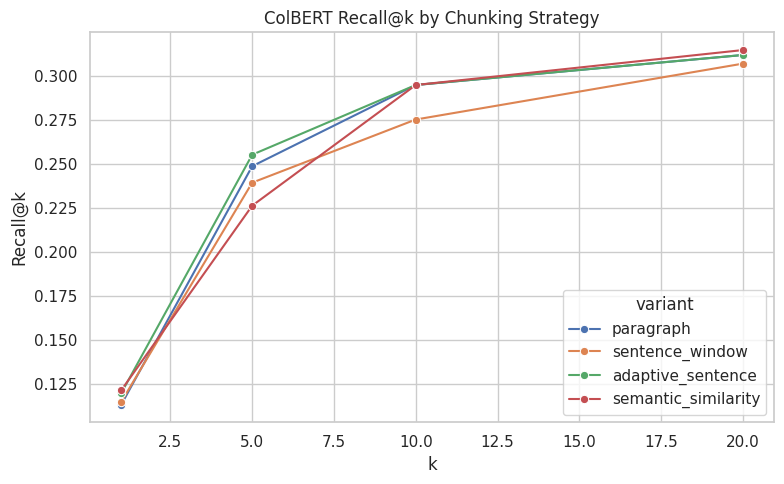

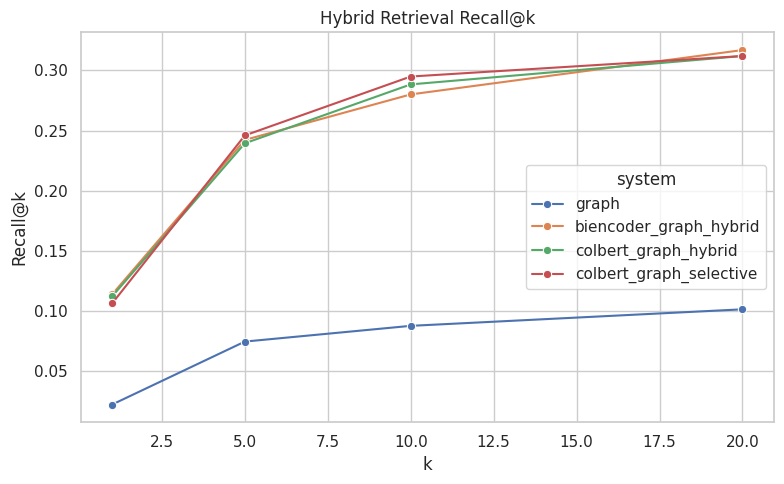

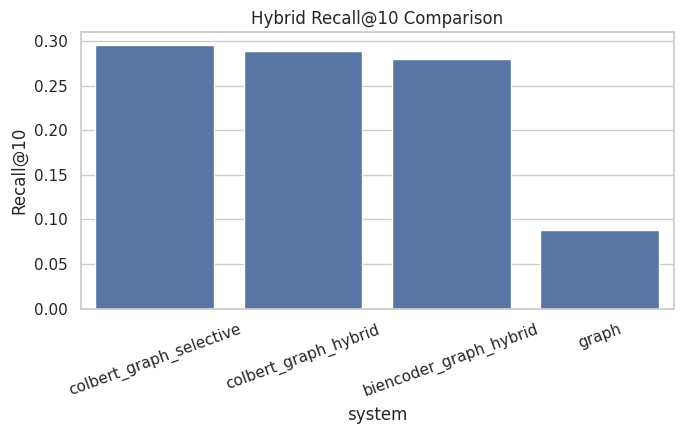

In [18]:
comparison_chart_dir = Path("results") / "notebook" / "final_comparison_charts"
comparison_chart_dir.mkdir(parents=True, exist_ok=True)

if not variant_overview.empty:
    chunk_chart_df = variant_overview.melt(
        id_vars=["variant"],
        value_vars=["colbert_recall_at_1", "colbert_recall_at_5", "colbert_recall_at_10", "colbert_recall_at_20"],
        var_name="metric",
        value_name="recall",
    )
    chunk_chart_df["k"] = chunk_chart_df["metric"].str.extract(r"(\d+)").astype(int)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(data=chunk_chart_df, x="k", y="recall", hue="variant", marker="o", ax=ax)
    ax.set_title("ColBERT Recall@k by Chunking Strategy")
    ax.set_xlabel("k")
    ax.set_ylabel("Recall@k")
    fig.tight_layout()
    fig.savefig(comparison_chart_dir / "chunking_colbert_recall.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No completed variant summaries found yet.")

if not hybrid_overview.empty:
    hybrid_chart_df = hybrid_overview.melt(
        id_vars=["system"],
        value_vars=["recall_at_1", "recall_at_5", "recall_at_10", "recall_at_20"],
        var_name="metric",
        value_name="recall",
    )
    hybrid_chart_df["k"] = hybrid_chart_df["metric"].str.extract(r"(\d+)").astype(int)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(data=hybrid_chart_df, x="k", y="recall", hue="system", marker="o", ax=ax)
    ax.set_title("Hybrid Retrieval Recall@k")
    ax.set_xlabel("k")
    ax.set_ylabel("Recall@k")
    fig.tight_layout()
    fig.savefig(comparison_chart_dir / "hybrid_recall.png", dpi=150, bbox_inches="tight")
    plt.show()

    recall10 = hybrid_overview[["system", "recall_at_10"]].copy().sort_values("recall_at_10", ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.barplot(data=recall10, x="system", y="recall_at_10", ax=ax)
    ax.set_title("Hybrid Recall@10 Comparison")
    ax.set_xlabel("system")
    ax.set_ylabel("Recall@10")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(comparison_chart_dir / "hybrid_recall_at_10.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Hybrid comparison results not found yet.")
